# Taller 6: Morfología matemática

## Librerias

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

from skimage.morphology import dilation, erosion, opening, closing, reconstruction
from skimage.morphology import footprint_rectangle

from scipy.ndimage import morphological_gradient
from skimage.filters import sobel
from skimage.filters.rank import mean
from skimage import exposure
from skimage.measure import label


from skimage import color, filters, morphology, measure, feature
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import binary_erosion
from skimage.morphology import skeletonize, thin
from skimage.morphology import footprint_rectangle , disk
from skimage.segmentation import flood

## Operadores de dilatación y erosión

In [2]:
def show_img(img, title='Imagen', plot=False, cmap='gray'):
  """ Muestra img, plot controla si se usa ´plt.plot´ """

  if plot:
    plt.plot(img)
  else:
    plt.imshow(img,cmap=cmap)
    plt.axis("off")

  
  plt.title(title)
  plt.tight_layout()
  plt.show()

In [3]:
def show_histogram(img,img_name=''):
  """Muestra el histograma de img"""

  hist = cv2.calcHist([img],[0],None,[256],[0,256])

  show_img(hist, title=f'Histograma {img_name}',plot=True)

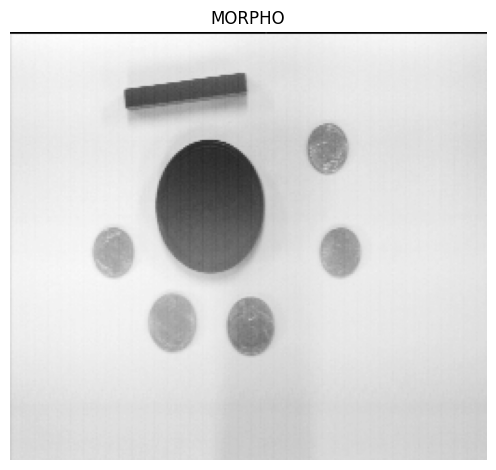

In [4]:
# Carga y visualizacion
morpho_img = cv2.imread( '../img/MORPHO.png', flags=cv2.IMREAD_GRAYSCALE )

show_img(morpho_img, 'MORPHO')

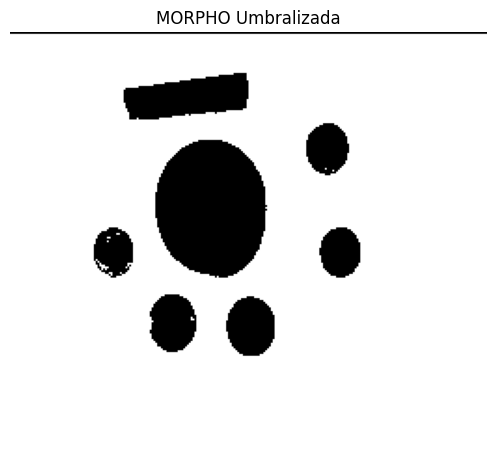

In [5]:
# Umbralizacion de la imagen
_, thresholded_morpho_img = cv2.threshold(morpho_img, 113, 256, cv2.THRESH_BINARY)

show_img(thresholded_morpho_img,'MORPHO Umbralizada')

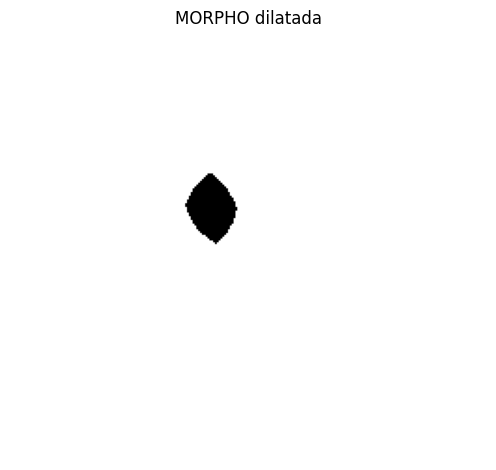

In [6]:
# elemento estructurante
fp = footprint_rectangle((29,29))

# dilatacion de la imagen
dilated_morpho_img = dilation(thresholded_morpho_img, footprint=fp)

show_img(dilated_morpho_img, 'MORPHO dilatada')

Lo que está sucediendo al aplicar la operación morfologica de dilatación sobre la imagen morpho umbralizada es la expansión de las estructuras claras de la imagen. Esta operación recorre cada pixel de la imagen centrando el objeto estructurante en esa posición y, en caso de que cualquier pixel claro o con valor 1 del elemento esté dentro de un objeto claro de la imagen, este pixel de salida en la posición será marcado con blanco. Como resultado de esta operación los objetos negros disminuyen su tamaño y los mas pequeños desaparecieron por completo.

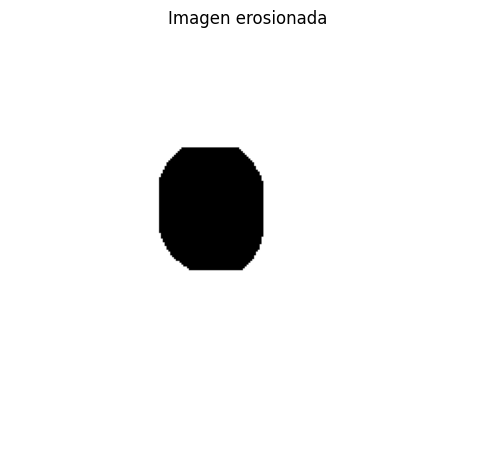

In [7]:
eroded_img = erosion(dilated_morpho_img, footprint=fp)

show_img(eroded_img, 'Imagen erosionada')

Al erosionar la imagen anterior, se aplica la operación contraria a la dilatación. En cada posición de la imagen se evalua si todas las posiciones del elemento estructurante están contenidas en las estructuras claras de la imagen y, en caso de que no se cumpla, se toma el pixel de salida como fondo y por lo tanto se asigna como 0 o negro. Esto da el resultado anterior donde el elemento en negro crece en tamaño tomando parte de la zona blanca, que en este caso tambien se toma como estructura de la imagen. Aunque esta operación realiza las operaciones contrarias a la dilatación. no se restableció la imagen umbralizada ya que sufrió pérdida de información por parte de la dilatación, al eliminar las estructuras medianas. Aun así, la estructura que se mantuvo en la imagen tambien es diferente a la original. Esta estructura ahora tiene una forma más cuadrada que la forma circular original.

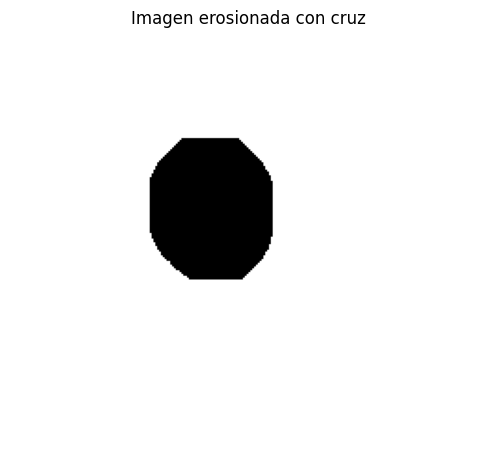

In [8]:
cross_se = np.empty((11,11))

cross_se[:,5] = 1
cross_se[5,:] = 1

eroded_img = erosion(eroded_img, footprint=cross_se)

show_img(eroded_img, 'Imagen erosionada con cruz')

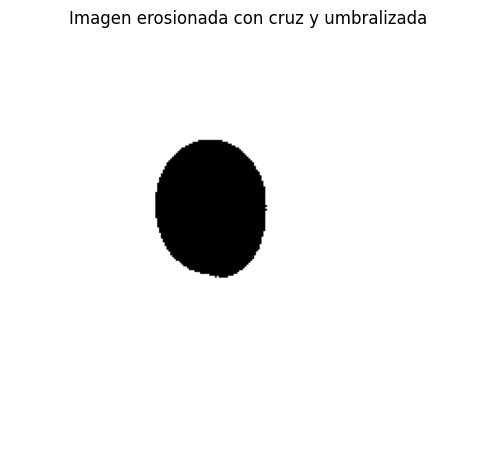

In [9]:
# maximo entre la imagen erosionada con cruz y la imagen umbralizada
show_img(np.maximum(eroded_img, thresholded_morpho_img), 'Imagen erosionada con cruz y umbralizada')

La imagen del resultado anterior muestra la intersección de las dos imagenes en la que solo se conserva la estructura negra mediana. La operacion de erosión con el elemento estructurante en forma de cruz deforma a la estructura y la realza para formar un cuadrado. Asi el resultado del maximo entre esta dos imagenes es la estructura mediana erosionada con una parte cuadrada producto de la operacion con el elemento estructurante en cruz.

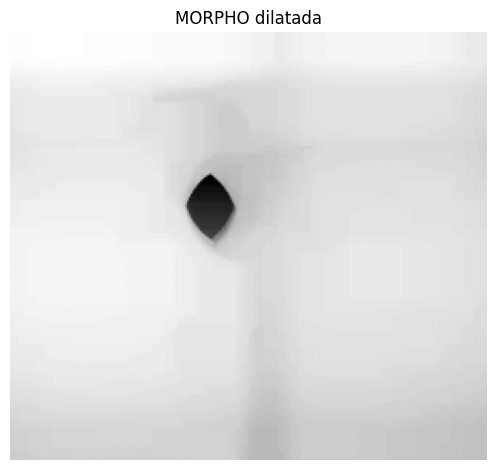

In [10]:
# elemento estructurante
fp = footprint_rectangle((29,29))

# dilatacion de la imagen
dilated_morpho_img = dilation(morpho_img, footprint=fp)

show_img(dilated_morpho_img, 'MORPHO dilatada')

Al aplicar la operacion de dilatacion sobre la imagen original se realzan los tonos claros, es decir, como efecto se tendrá un realce de brillo general  de la imagen. Al igual que en los resultados anteriores, las estructuras claras aumentan de tamaño lo que hace que los objetos oscuros disminuyan. Además la operacion se ve afectada por el ruido de la imagen o varaciones pequeñas en iluminacción lo que hace que la imagen tengra muchas zonas con diferente nivel de color.

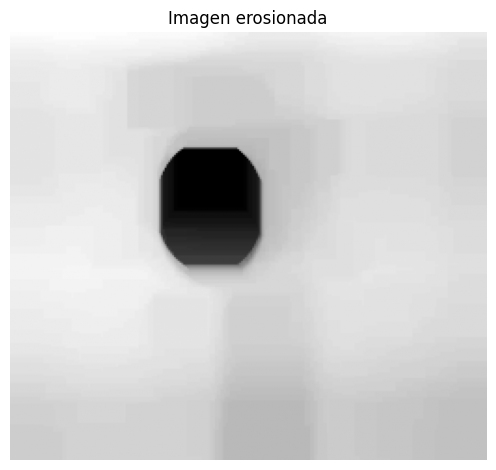

In [11]:
eroded_img = erosion(dilated_morpho_img, footprint=fp)

show_img(eroded_img, 'Imagen erosionada')

Al erosionar la imagen anterior, ocurre lo contrario a la operacion de dilatación. Las zonas claras pierden tamaño mientras que los objetos negros aumentan su tamaño. Como resutado de la dilación, los objetos medianos desaparecieron y la estructura mediana perdió información sobre su forma y con la operacion de erosión, adquierió una forma cuadrada a causa de la forma del elemento estructurante. 

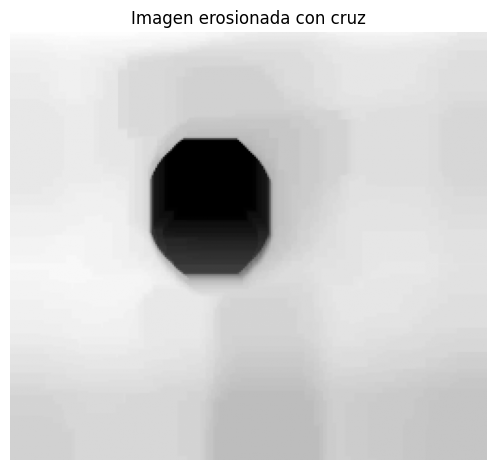

In [12]:
cross_se = np.empty((11,11))

cross_se[:,5] = 1
cross_se[5,:] = 1

eroded_img = erosion(eroded_img, footprint=cross_se)

show_img(eroded_img, 'Imagen erosionada con cruz')

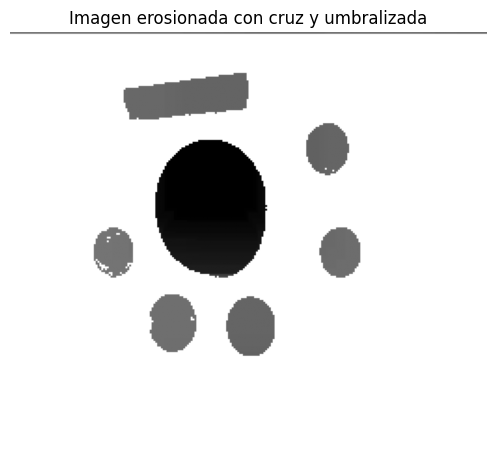

In [13]:
# maximo entre la imagen erosionada con cruz y la imagen umbralizada
show_img(np.maximum(eroded_img, thresholded_morpho_img), 'Imagen erosionada con cruz y umbralizada')

La imagen del resultado anterior muestra la intersección de las dos imagenes en la que los elementos medianos de la imagen umbralizada se mantienen pero adquierer un tono gris de la imagen de escala de grises, mientras que el elemento grande sufrió un recorte a causa de las operaciones morfologicas aplicadas a la imagen original.

Las operaciones morfológicas en niveles de gris funcionan reemplazando el valor de cada píxel por un valor calculado en su vecindad, definida esta por un elemento estructurante. En el caso de la dilatación, el valor del píxel central se sustituye por el valor máximo encontrado dentro de la ventana del kernel. Esto provoca que las regiones más brillantes de la imagen se expandan y los detalles oscuros, como el ruido tipo "pimienta" o pequeñas grietas, se rellenen o desaparezcan, aumentando el brillo general de la toma.

Por el contrario, la erosión opera seleccionando el valor mínimo dentro de la vecindad del elemento estructurante. Al asignar el valor más bajo al píxel central, las zonas oscuras crecen y los objetos claros se reducen en tamaño o se adelgazan. Esta operación es ideal para eliminar ruido brillante de tipo "sal" y para separar objetos claros que están ligeramente conectados, aunque tiene como efecto secundario un oscurecimiento general de la imagen al prevalecer las intensidades bajas sobre las altas.

Aplicar estas operaciones sobre la imagen original es diferente al resultado con la imagen umbralizada en cuanto a los niveles de gris resultantes y al nivel de detalle con el que se aplica la operación. Aplicando las operaciones directamente sobre la imagen original las operaciones tienden a capturar detalle de variaciones de iluminación y aumentarlas lo cual no es deseable. Por otro lado, treabajar con la imagen umbralizada da un resultado más adecuado para segmentación de imagenes.

## Gradiente morfológico

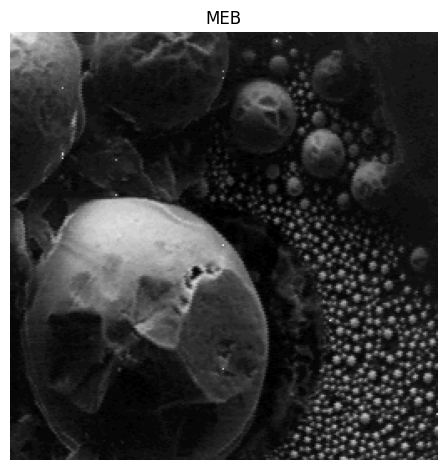

In [14]:
# carga y visualizacion
meb_img = cv2.imread('../img/MEB.png',cv2.IMREAD_GRAYSCALE)

show_img(meb_img,'MEB')

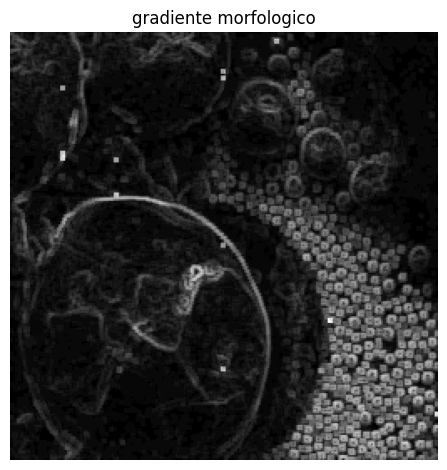

In [15]:
# gradiente morfologico 3x3
mgimage = morphological_gradient(meb_img, size=(3,3))

show_img(mgimage, 'gradiente morfologico')

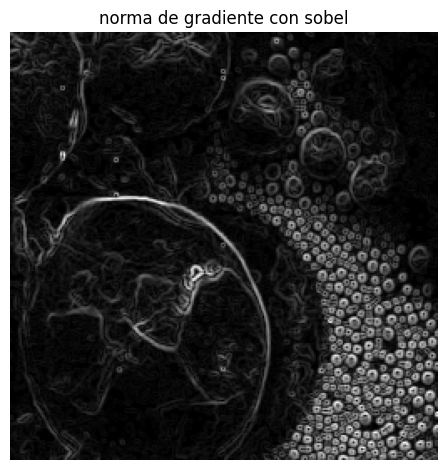

In [16]:
#Norma del gradiente con sobel
img_s = sobel(meb_img)

show_img(img_s, 'norma de gradiente con sobel')

La diferencia entre el gradiente morfológico y la norma del gradiente de Sobel en que el gradiente morfologico es una operación no lineal basada en la geometría de los objetos, mientras que el segundo es una operación lineal basada en el cálculo diferencial. El gradiente morfológico se obtiene mediante las operaciones de erosión y dilatación, lo que genera un contorno de grosor definido por el tamaño del elemento estructurante, siendo una herramienta espacial que no considera la magnitud del cambio de intensidad más allá de los valores máximos y mínimos locales. Por el contrario, la norma de Sobel utiliza kernels de convolución para aproximar las derivadas parciales en las direcciones horizontal y vertical, lo que resulta en una respuesta cuya intensidad es proporcional a la rapidez de la transición de los niveles de gris en la imagen; esto hace que Sobel sea capaz de detectar bordes suaves o fuertes con distinta relevancia visual. Como se observó con la imagen original, el gradiente morfológico es muy sensible al ruido e iluminación. Sobel, aunque también se ve afectado por el ruido, posee un ligero efecto de suavizado debido a los coeficientes de su máscara dando resultados más limpios en imágenes con ruido.

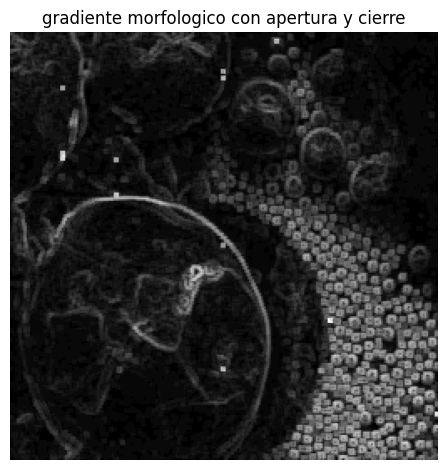

In [17]:
# Gradiente morfologico con apertura y cierre

# Elemento estructurante
elemento_estructurante = np.ones((3,3), np.uint8)

# Calcular el gradiente morfológico
dilated_morpho_img = dilation(meb_img, footprint=elemento_estructurante)
eroded_morpho_img = erosion(meb_img, footprint=elemento_estructurante)

gradiente = dilated_morpho_img - eroded_morpho_img

show_img(gradiente, 'gradiente morfologico con apertura y cierre')

El resultado obtenido es igual al obtenido con la función morphological_gradient. Esta imagen permite resaltar los contornos de los objetos al aplicar dilatación para hacer que los elementos en ella aumenten de tamaño, al mismo tiempo que se aplica erosion para disminuir el tamaño de los objetos, y finalmente detectar contornos usando la diferencia entre estas imagenes.

## Operadores de apertura y cierre

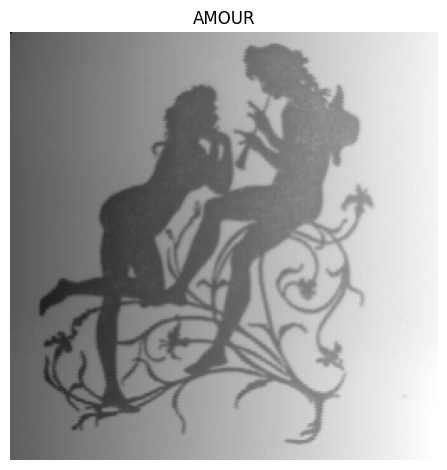

In [18]:
# Carga y visualizacion
amout_img = cv2.imread('../img/AMOUR.png',cv2.IMREAD_GRAYSCALE)

show_img(amout_img, 'AMOUR')

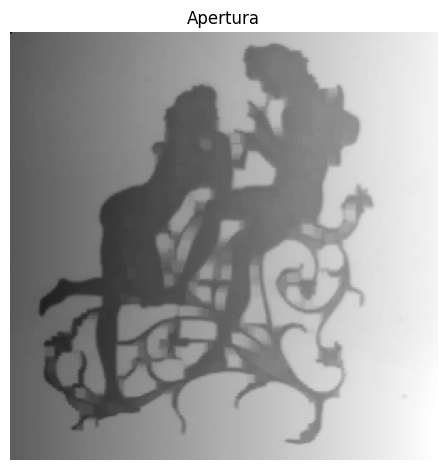

In [19]:
# apertura de la imagen
opening_image = opening(amout_img, footprint=footprint_rectangle((5,5)))

show_img(opening_image,'Apertura')

Con la operación apertura algunos detalles son suprimidos como la silueta o contorno de los objetos se vuelve más difusa y por tanto la imagen adquiere un efecto borroso. Además las curvas pierden parte de la curvatura y s vuelven más rectas por causa de la forma cuadrada del elementos estructurante.

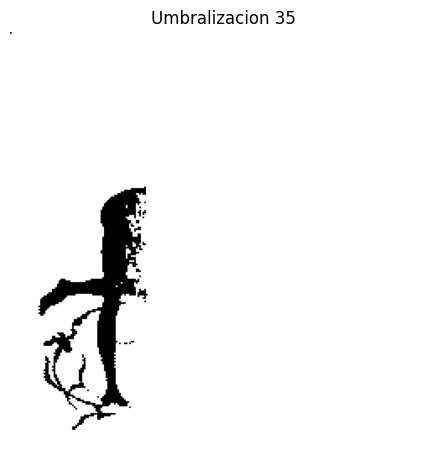

In [20]:
# umbralizacion de la imagen original
_, thres_image = cv2.threshold(amout_img, 35, 256, cv2.THRESH_BINARY)


show_img(thres_image,'Umbralizacion 35')

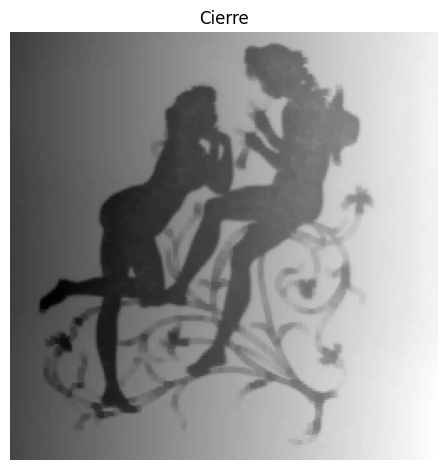

In [21]:
k1 = np.empty((3,3))
k2 = np.empty((3,3))
k3 = np.ones((1,3))
k4 = np.ones((3,1))


for i in range(3):
  k1[2-i,i] = 1

  k2[i,i] = 1

# aplicación de cierre con los elementos estructurantes
closing_image = closing(amout_img, footprint=k1)
closing_image = closing(closing_image, footprint=k2)
closing_image = closing(closing_image, footprint=k3)
closing_image = closing(closing_image, footprint=k4)

show_img(closing_image,'Cierre')

El efecto de aplicar consecutivamente los elementos estructurantes definidos previamente, 

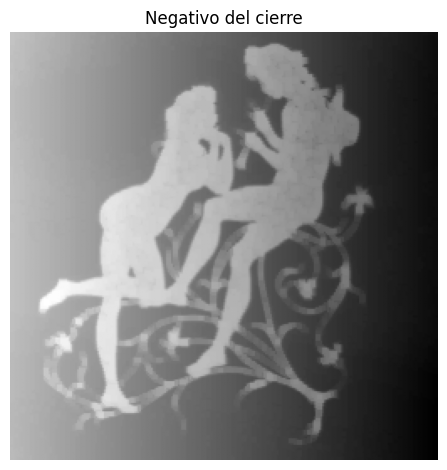

In [22]:
negativo = cv2.bitwise_not(closing_image)

show_img(negativo,'Negativo del cierre')

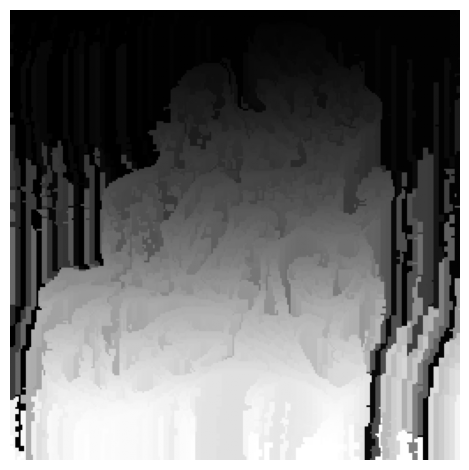

In [23]:
connected_components = label(negativo, background=0, connectivity=2)

show_img(connected_components,'')

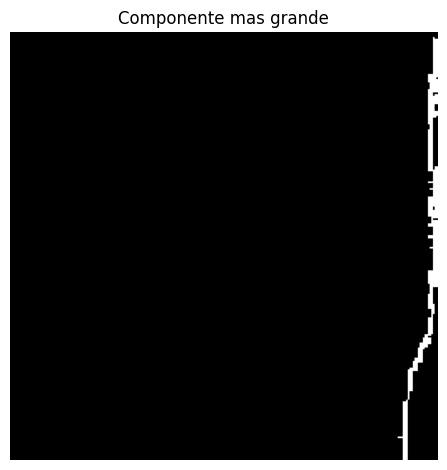

In [24]:
vals, counts = np.unique(connected_components, return_counts=True)
max_idx = np.argmax(counts)

# nivel del componente mas grande
nivel = vals[max_idx]

# mascara del componente mas grande
componente_mas_grande = np.where(connected_components==nivel, 255, 0)

show_img(componente_mas_grande,'Componente mas grande')

La imagen anterior muestra el componenta más grande de la imagen Amour. Esto se realizó mediante un escaneamiento de la imagen para agrupar píxeles adyacentes que tienen el mismo valor o nivel de color, asignándoles un número entero único o etiqueta a cada grupo detectado. Esencialmente, transforma una máscara de "objetos vs. fondo" en un mapa donde cada "isla" de píxeles conectados se identifica como un objeto individual. Su comportamiento depende del tipo de conectividad: una conectividad de $1$ solo une píxeles que comparten un lado (arriba, abajo, izquierda, derecha), mientras que una conectividad de $2$ también incluye las diagonales, tratando como un solo objeto a elementos que apenas se tocan por las esquinas.

# Etiquetado de objetos


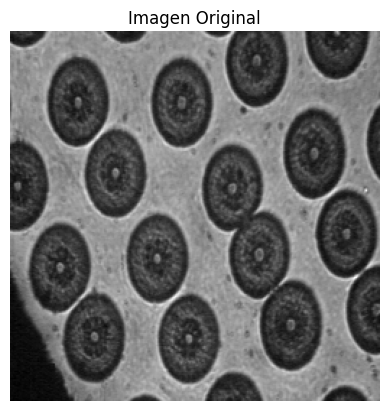

In [26]:
SIC= cv2.imread('../img/SIC.png',cv2.IMREAD_GRAYSCALE)
plt.imshow(SIC, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.show()

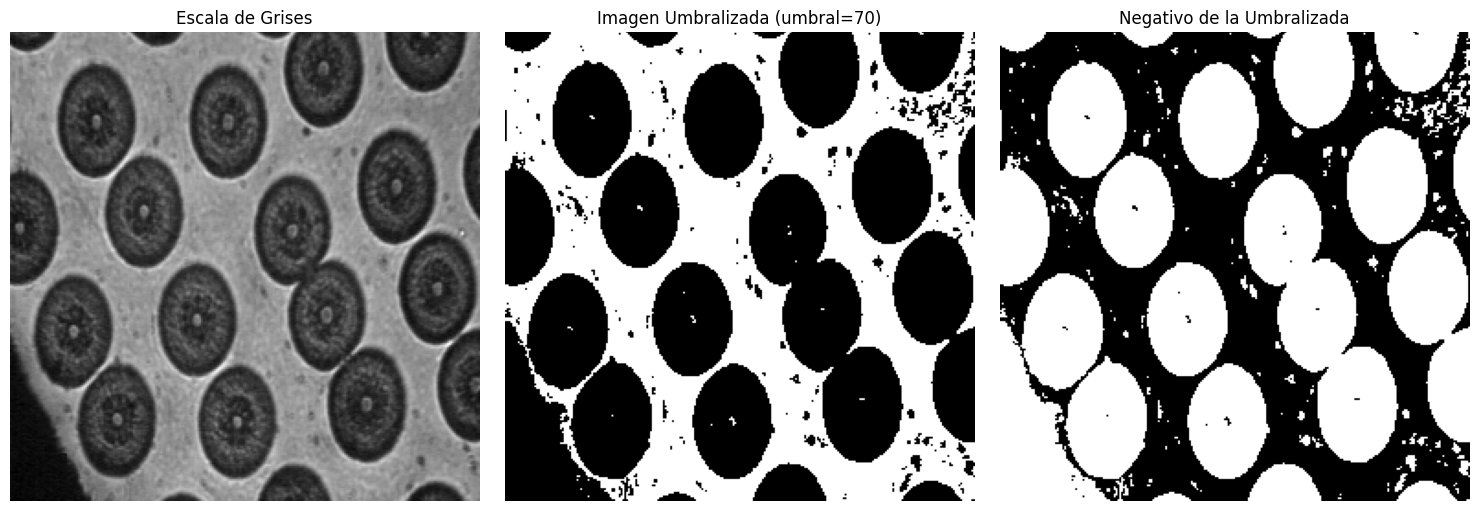

Valor de umbral utilizado: 70.0


In [27]:


# Umbralización: umbral = 65 (entre 55 y 70) para separar las células del fondo
thres = 70
max_value = 255
flag = cv2.THRESH_BINARY

thres_value, thres_image = cv2.threshold(SIC, thres, max_value, flag)

# Negativo de la imagen umbralizada
negative_image = cv2.bitwise_not(thres_image)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(SIC, cmap='gray')
axes[0].set_title('Escala de Grises')
axes[0].axis('off')

axes[1].imshow(thres_image, cmap='gray')
axes[1].set_title(f'Imagen Umbralizada (umbral={thres})')
axes[1].axis('off')

axes[2].imshow(negative_image, cmap='gray')
axes[2].set_title('Negativo de la Umbralizada')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Valor de umbral utilizado: {thres_value}")


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

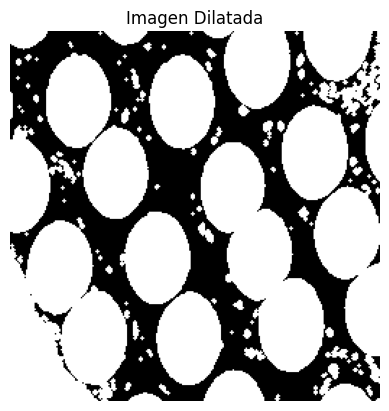

In [28]:
mascara = np.array([[None, 1, None], [1, 1, 1], [None, 1, None]])

dilated_image = dilation(negative_image, footprint=mascara)

plt.imshow(dilated_image, cmap = "gray")
plt.title('Imagen Dilatada')
plt.axis('off')

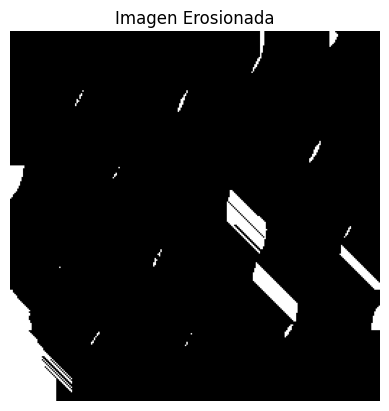

In [29]:
oblicua1 = np.array([[1, None, None], [None, 1, None], [None, None, 1]])  # máscara \
oblicua2 = np.transpose(oblicua1)                          # máscara /

# Erosión: 10 veces con máscara / (oblicua2) y 6 veces con máscara \ (oblicua1)
eroded = erosion(negative_image, footprint=[(oblicua2, 10),(oblicua1, 7)])

plt.imshow(eroded, cmap="gray")
plt.title('Imagen Erosionada')
plt.axis('off')
plt.show()


Número de células detectadas: 22
Nota: Las células que tocan el borde de la imagen aparecen incompletas/cortadas y/o mezcaldas con este mismo y no se pueden contar correctamente.


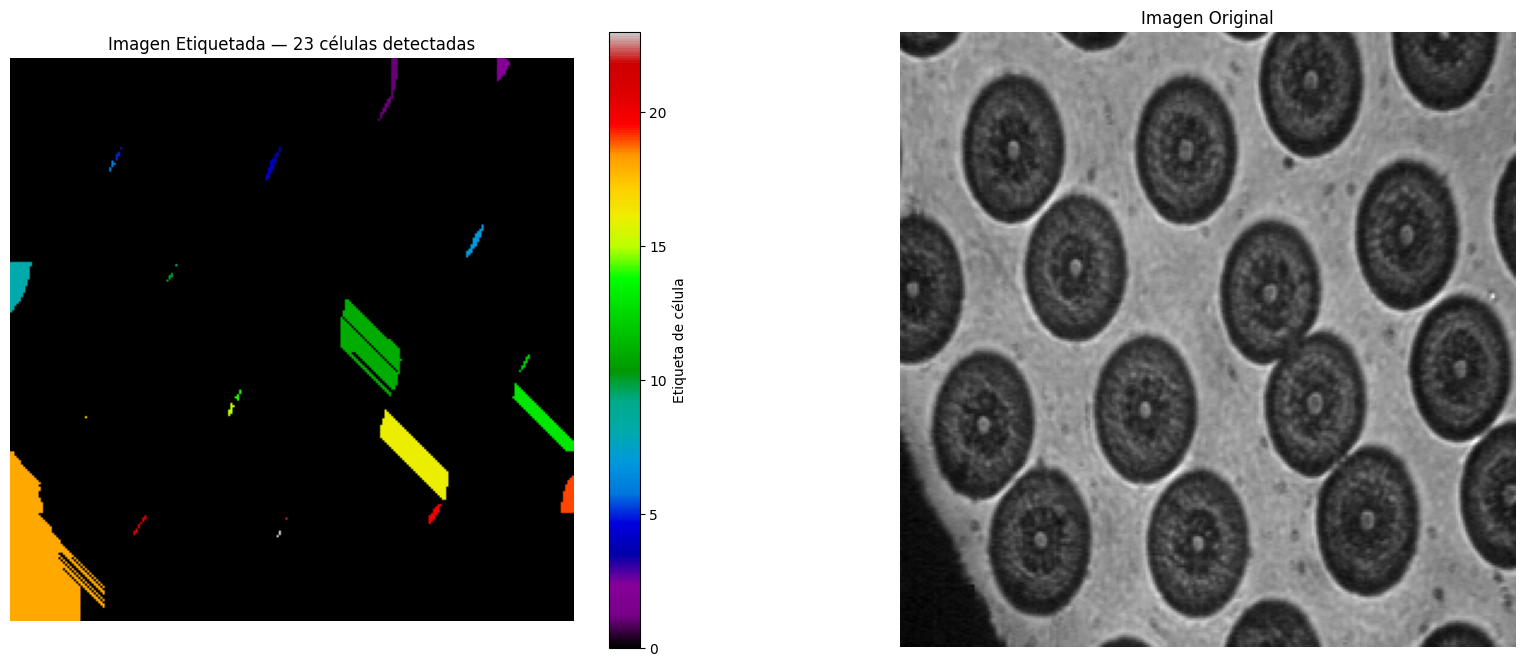

In [30]:
connected_components = label(eroded)
num_cells = connected_components.max()

print(f"Número de células detectadas: {num_cells-1}") # Restamos 1 para no contar el fondo como una célula
print("Nota: Las células que tocan el borde de la imagen aparecen incompletas/cortadas y/o mezcaldas con este mismo y no se pueden contar correctamente.")
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(connected_components, cmap='nipy_spectral')
plt.title(f'Imagen Etiquetada — {num_cells} células detectadas')
plt.axis('off')
plt.colorbar(label='Etiqueta de célula')

plt.subplot(1, 2, 2)
plt.imshow(SIC, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')

plt.show()


Las células que se encuentran en los bordes de la imagen aparecen incompletas o cortadas y no se pueden contar. Esto se debe a que el operador de erosión requiere que el elemento estructurante (la máscara) quepa completamente dentro de la región de la imagen. Cuando una célula toca o cruza el límite de la imagen, la máscara no puede aplicarse en su totalidad sobre esa zona, por lo que la célula es erosionada de forma parcial o eliminada por completo. Como resultado, las regiones en el borde no representan células enteras y no deben contarse como detecciones válidas.

# Imagen de distancia


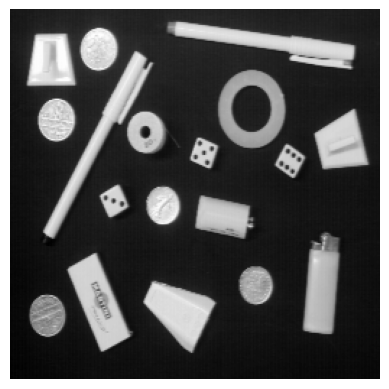

In [31]:
OBJECTS= cv2.imread("../img/OBJECTS.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(OBJECTS, cmap='gray')
plt.axis("off")

plt.show()


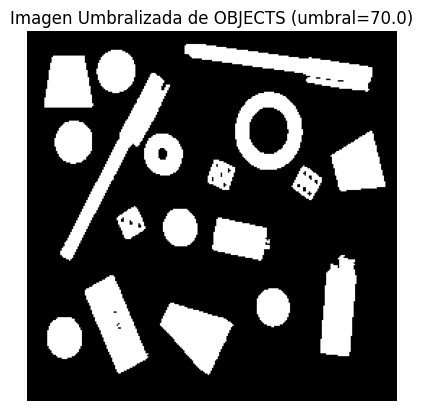

In [32]:
thres_value, OBJECTS_TRESH = cv2.threshold(OBJECTS, 70, 255, cv2.THRESH_BINARY)
plt.imshow(OBJECTS_TRESH, cmap='gray')
plt.title(f'Imagen Umbralizada de OBJECTS (umbral={thres_value})')
plt.axis('off')
plt.show()

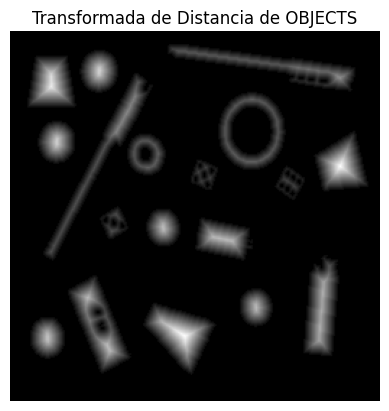

In [33]:
distance = distance_transform_edt(OBJECTS_TRESH)
distance_e = exposure.rescale_intensity(distance , in_range=(np.min(distance),np.max(distance)) , out_range=(0,255))
plt.imshow(distance_e, cmap='gray')
plt.title('Transformada de Distancia de OBJECTS')
plt.axis('off')
plt.show()


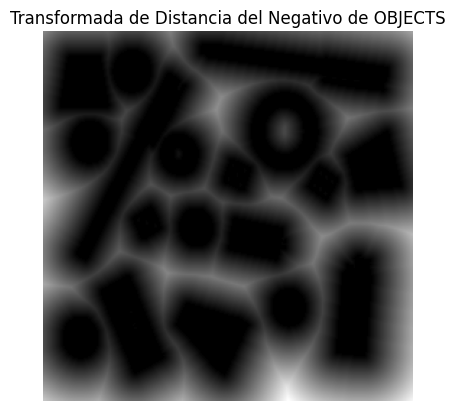

In [34]:
negative = cv2.bitwise_not(OBJECTS_TRESH)
distance_n = distance_transform_edt(negative)
distance_n_e = exposure.rescale_intensity(distance_n , in_range=(np.min(distance_n),np.max(distance_n)) , out_range=(0,255))

plt.imshow(distance_n_e, cmap='gray')
plt.title('Transformada de Distancia del Negativo de OBJECTS')
plt.axis('off')
plt.show()


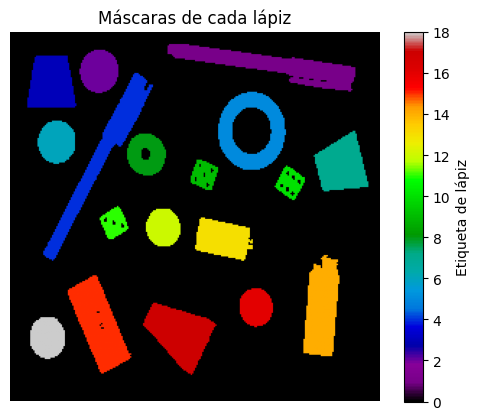

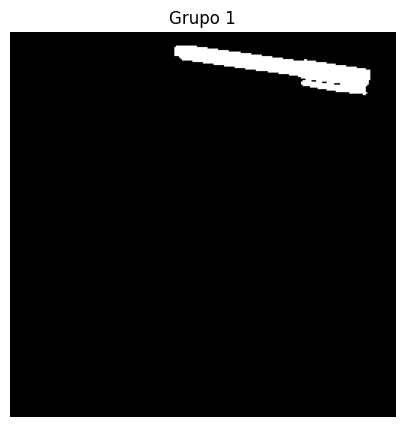

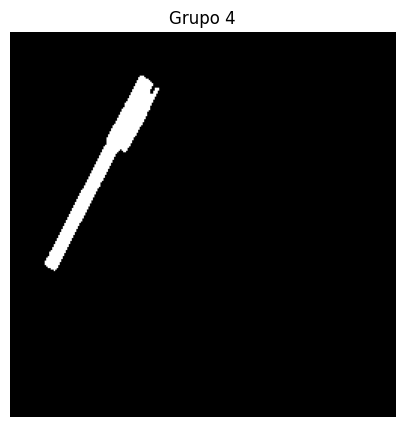

In [35]:

# --- Máscaras de cada lápiz ---
labeled_pencils = label(OBJECTS_TRESH)

plt.imshow(labeled_pencils, cmap='nipy_spectral')
plt.title('Máscaras de cada lápiz')
plt.axis('off')
plt.colorbar(label='Etiqueta de lápiz')
plt.show()
# Mostrar solo los lapices
# Ver cual grupo corresponde a cada lápiz y mostrarlo por separado
"""
for i in range (labeled_pencils.max()+1):
       graf= labeled_pencils == i 
       plt.figure(figsize=(10, 5))
       plt.imshow(graf, cmap='gray')
       plt.title(f'Grupo {i}')
       plt.axis('off')
       plt.show()
"""
graf= labeled_pencils == 1 
plt.figure(figsize=(10, 5))
plt.imshow(graf, cmap='gray')
plt.title(f'Grupo {1}')
plt.axis('off')
plt.show()
graf= labeled_pencils == 4 
plt.figure(figsize=(10, 5))
plt.imshow(graf, cmap='gray')
plt.title(f'Grupo {4}')
plt.axis('off')
plt.show()

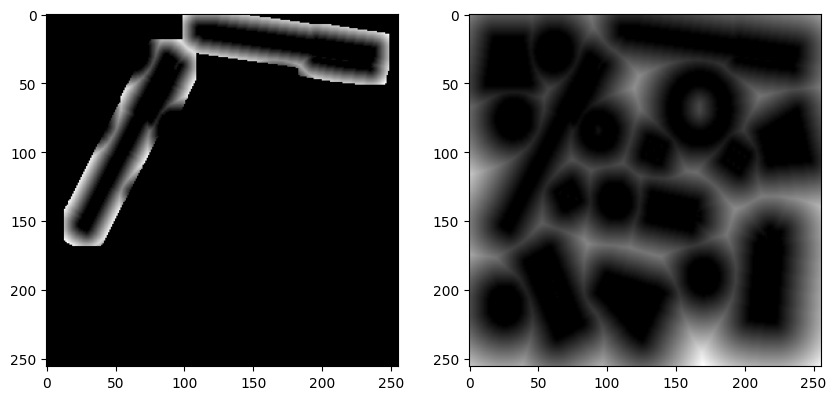

La distancia entre los lápices es de aproximadamente 14.142135623730951 píxeles.


In [36]:
pencil1 = (labeled_pencils == 1).astype(np.uint8) * 255
pencil2 = (labeled_pencils == 4).astype(np.uint8) * 255

subs1 = cv2.bitwise_or(pencil2.astype(np.float32), pencil1.astype(np.float32))

dilated= dilation( subs1, footprint= [(footprint_rectangle((21, 21)),1)])
pendistance = np.where(dilated > 0, distance_n, 0)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(pendistance,cmap="grey")
plt.subplot(1, 2, 2)
plt.imshow(distance_n,cmap="grey")
plt.show()

print(f"La distancia entre los lápices es de aproximadamente {pendistance.max()} píxeles.")


# Esqueleto y adelgazamiento de una imagen


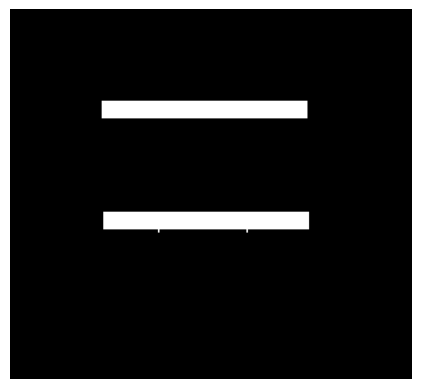

In [38]:
RECT = cv2.imread("../img/RECT.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(RECT, cmap = "grey")
plt.axis("off")
plt.show()

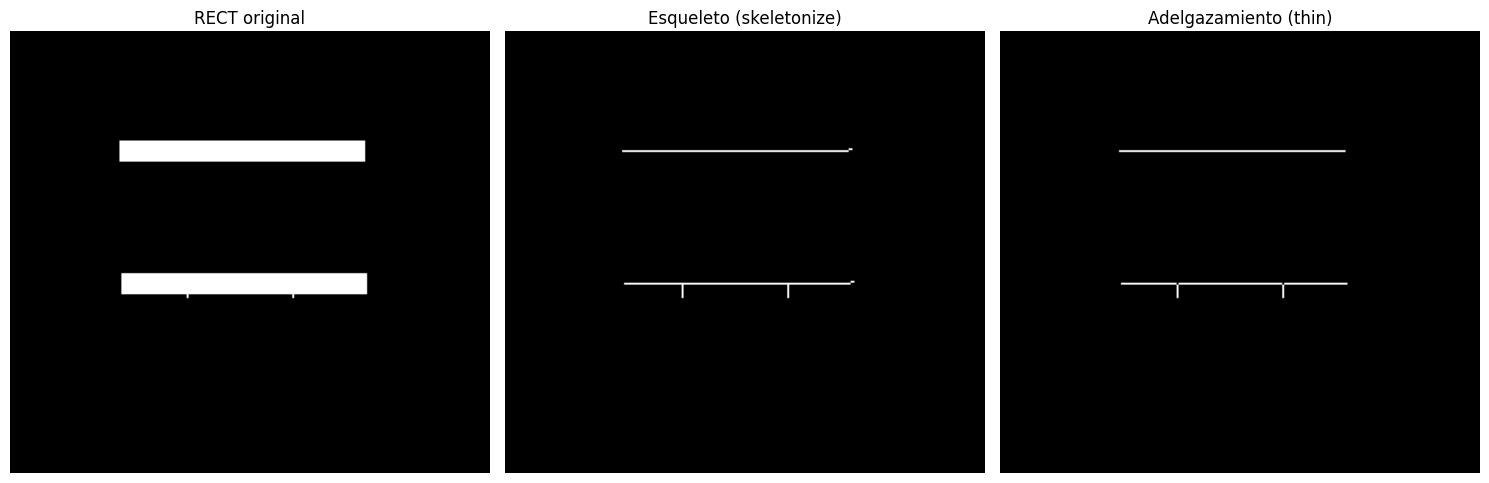

Píxeles solo en esqueleto  : 8
Píxeles solo en thin       : 2
Píxeles en común           : 246


In [39]:
sk_image = skeletonize(RECT > 0)   # esqueletización (Zhang por defecto)
th_image = thin(RECT > 0)          # adelgazamiento

# Calibración: convertir booleano a uint8 y escalar a 0-255 para mejor visualización
sk_vis = exposure.rescale_intensity(sk_image.astype(np.uint8) * 255,
                                    in_range=(0, 1), out_range=(0, 255))
th_vis = exposure.rescale_intensity(th_image.astype(np.uint8) * 255,
                                    in_range=(0, 1), out_range=(0, 255))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(RECT, cmap='gray')
axes[0].set_title('RECT original')
axes[0].axis('off')

axes[1].imshow(sk_vis, cmap='gray')
axes[1].set_title('Esqueleto (skeletonize)')
axes[1].axis('off')

axes[2].imshow(th_vis, cmap='gray')
axes[2].set_title('Adelgazamiento (thin)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Diferencia entre ambos resultados
diff = sk_image.astype(int) - th_image.astype(int)
print(f"Píxeles solo en esqueleto  : {(diff  > 0).sum()}")
print(f"Píxeles solo en thin       : {(diff  < 0).sum()}")
print(f"Píxeles en común           : {np.logical_and(sk_image, th_image).sum()}")


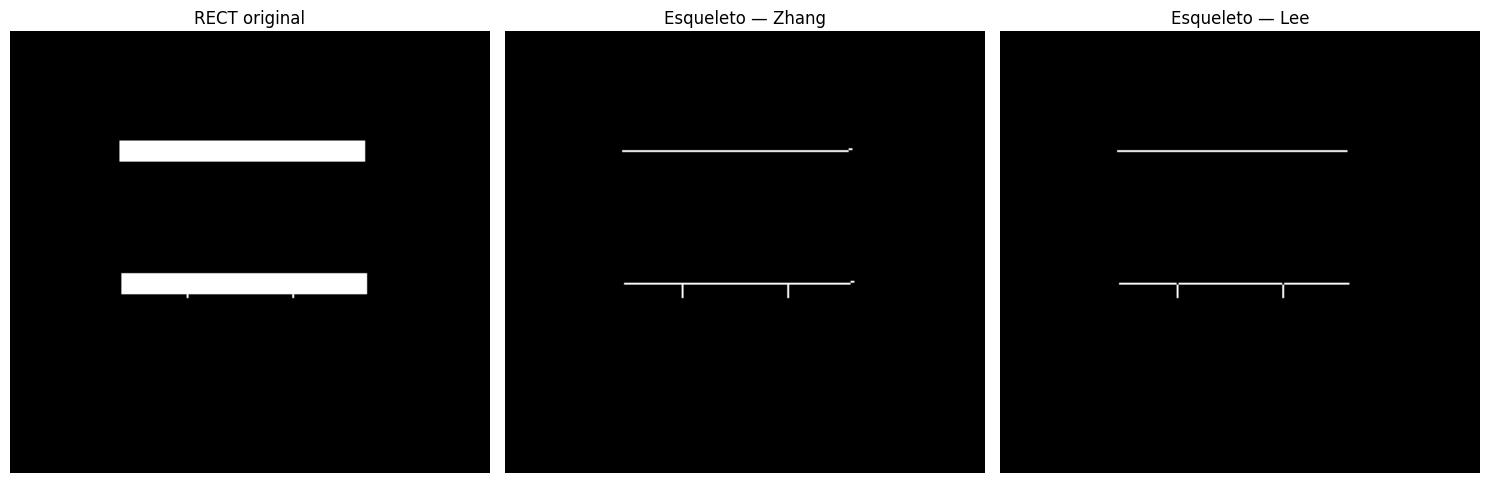

In [40]:


skel_zhang = skeletonize(RECT, method='zhang')
skel_lee   = skeletonize(RECT, method='lee')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(RECT, cmap='gray')
axes[0].set_title('RECT original')
axes[0].axis('off')

axes[1].imshow(skel_zhang, cmap='gray')
axes[1].set_title('Esqueleto — Zhang')
axes[1].axis('off')

axes[2].imshow(skel_lee, cmap='gray')
axes[2].set_title('Esqueleto — Lee')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Comparación Zhang vs Lee

**Algoritmo de Zhang-Suen** opera en dos sub-iteraciones por ciclo, eliminando píxeles de borde que cumplan condiciones basadas en sus **8 vecinos**. Trabaja en paralelo sobre toda la imagen en cada pasada, lo que lo hace rápido pero a veces produce esqueletos con pequeñas discontinuidades o artefactos en formas complejas.

**Algoritmo de Lee** (Lee-Kashyap-Chu) usa una estrategia de **lookup tables 3×3** y procesa los píxeles de forma secuencial. Es más robusto y garantiza conectividad del esqueleto, especialmente en formas con muchas ramificaciones o bordes irregulares, pero puede ser algo más lento.

**Diferencias observadas en RECT:**
- Zhang puede generar esqueletos ligeramente más finos con mayor riesgo de ruptura en esquinas.
- Lee conserva mejor la topología (conectividad) y produce esqueletos más continuos.
- Para figuras simples como rectángulos, ambos resultados son muy similares. Las diferencias se notan más en formas complejas o con ruido.


## Adelgazamiento vs Esqueletización

**Adelgazamiento (`thin`):**  
Erosiona iterativamente los bordes del objeto eliminando píxeles que no afecten la conectividad, hasta que ningún píxel pueda eliminarse. El resultado es una representación de 1 píxel de ancho que preserva la topología (agujeros, ramas). No garantiza que el resultado sea el eje central geométrico ,solo garantiza que quede lo más delgado posible manteniendo la forma conectada.

**Esqueletización (`skeletonize`):**  
Busca el el eje medial del objeto, es decir que mira los píxeles que están equidistantes a dos o más bordes del objeto. Es geométricamente más significativo, el esqueleto representa la "columna vertebral" de la forma. 


Para figuras simples como rectángulos, los resultados son visualmente muy similares. En este caso con unas pequeñas diferencias en los bordes. Las diferencias se evidencian en formas irregulares o con variaciones de grosor.


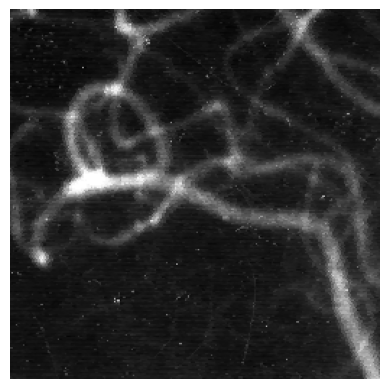

In [41]:
ANGIO = cv2.imread("../img/ANGIO.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(ANGIO, cmap='gray')
plt.axis("off")
plt.show()


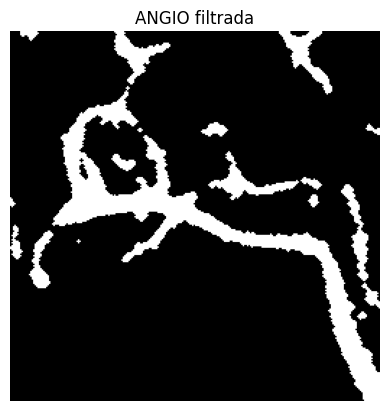

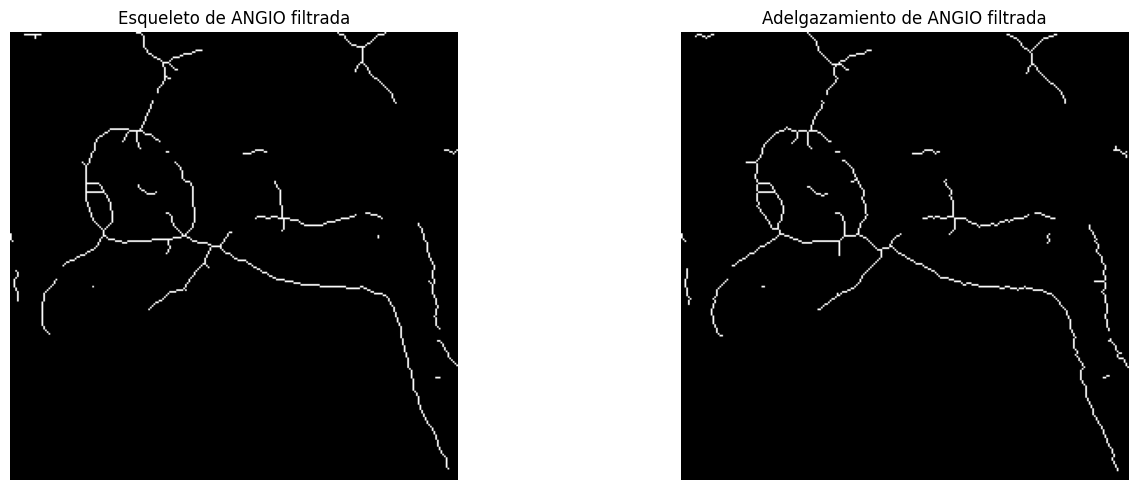

In [42]:
footprint= np.array([[None, 1, None], [1, 1, 1], [None, 1, None]])
_,ANGIO_TRESH = cv2.threshold(ANGIO, 0, max_value, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
ANGIO_FIL = opening(closing(ANGIO_TRESH,footprint= footprint),footprint= footprint)

plt.imshow(ANGIO_FIL, cmap='gray')
plt.title('ANGIO filtrada')
plt.axis('off')
plt.show()


sk_image = skeletonize(ANGIO_FIL)
th_image = thin(ANGIO_FIL)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.imshow(sk_image, cmap='gray')
plt.title('Esqueleto de ANGIO filtrada')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(th_image, cmap='gray')
plt.title('Adelgazamiento de ANGIO filtrada')
plt.axis('off')
plt.tight_layout()
plt.show()


Esqueleto (skeletonize) — izquierda:

Las líneas resultantes son muy delgadas (1 píxel) y trazan con precisión el eje central de cada vaso.
En la estructura anular (centro-izquierda) se genera un contorno cerrado limpio, reflejando la forma circular del vaso.
Las bifurcaciones y ramificaciones quedan bien definidas como puntos de cruce.
Se observan algunas ramas cortas sueltas (fragmentos aislados) en zonas donde vasos pequeños o ruido residual sobrevivieron al filtrado — son artefactos del eje medial en regiones estrechas.
Adelgazamiento (thin) — derecha:

Las líneas también son de 1 píxel pero en la zona anular central se aprecia que el thin genera un trazo ligeramente más grueso o relleno, preservando más la topología del área original.
Los vasos en los bordes de la imagen aparecen con más masa lateral respecto al esqueleto, ya que thin no busca el centro geométrico sino el mínimo posible sin romper conexiones.
Las bifurcaciones conservan mejor la continuidad, con menos fragmentos sueltos que en el esqueleto.
En los vasos largos y delgados (parte inferior y lateral) los dos métodos son prácticamente idénticos.
En resumen: para esta angiografía, skeletonize produce líneas más centradas y geométricamente precisas, mientras que thin es más conservador en zonas complejas como el anillo central, donde mantiene mejor la forma topológica origina

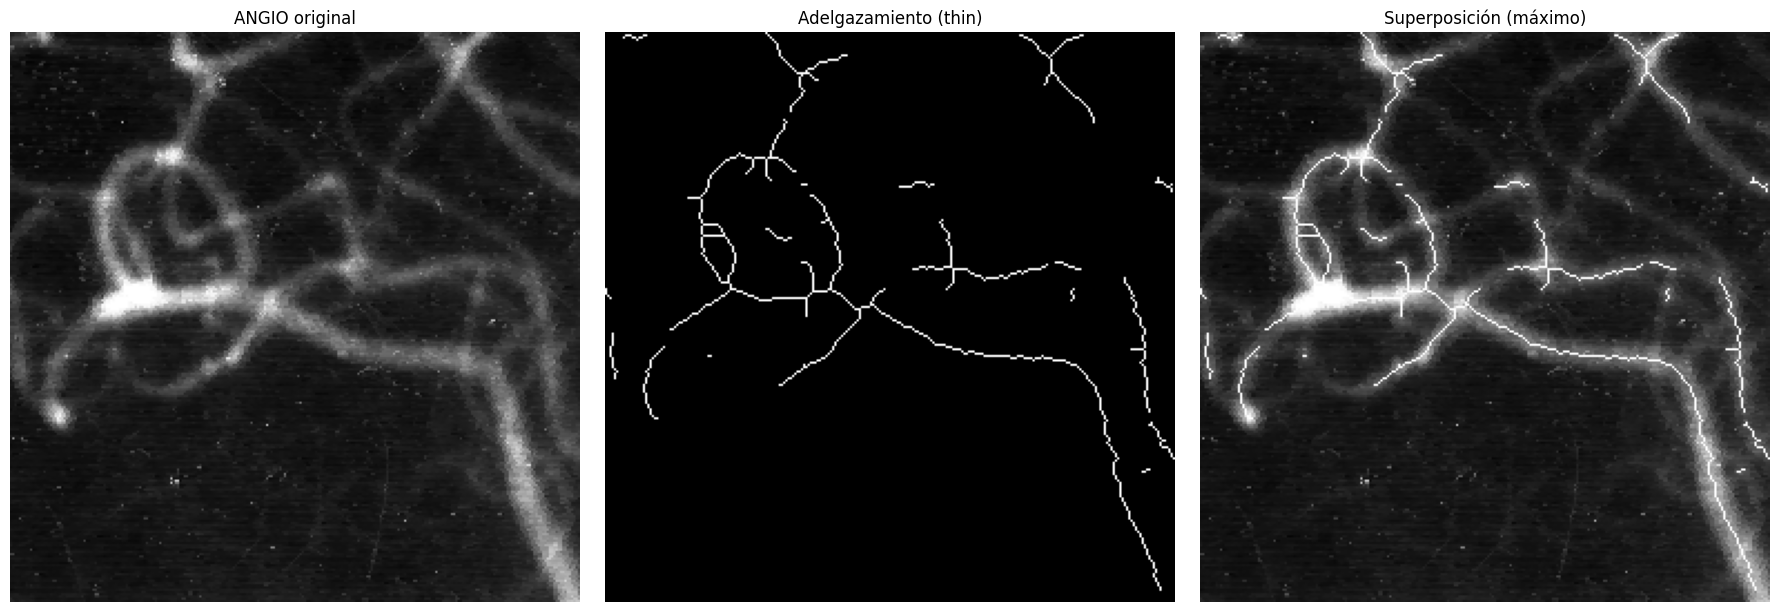

In [43]:
# Convertir th_image (booleano) a uint8 en rango 0-255
th_uint8 = (th_image.astype(np.uint8)) * 255

# Superposición: máximo píxel a píxel entre ANGIO original y la imagen adelgazada
overlay = np.maximum(ANGIO, th_uint8)

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ANGIO, cmap='gray')
axes[0].set_title('ANGIO original')
axes[0].axis('off')

axes[1].imshow(th_uint8, cmap='gray')
axes[1].set_title('Adelgazamiento (thin)')
axes[1].axis('off')

axes[2].imshow(overlay, cmap='gray')
axes[2].set_title('Superposición (máximo)')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Descripción cualitativa — Superposición de adelgazamiento sobre ANGIO

Al calcular el máximo píxel a píxel entre la imagen original `ANGIO` y el resultado del adelgazamiento, se observa lo siguiente:

- Las **líneas del adelgazamiento aparecen perfectamente centradas** dentro de los vasos visibles en la imagen original, confirmando que el operador `thin` preserva bien el eje central de cada estructura tubular.
- En los **vasos más gruesos**, la línea adelgazada queda visiblemente en el interior de la región brillante original, lo que evidencia la reducción correcta del grosor a 1 píxel.
- En los **vasos más delgados**, la línea adelgazada coincide casi exactamente con la región original, ya que estructuras de pocos píxeles de ancho casi no se modifican.
- La **operación máximo** actúa como una unión lógica: donde el adelgazamiento tiene píxeles blancos (255), los impone sobre la imagen original. Donde la imagen original tiene mayor intensidad, esta prevalece. El resultado es que la imagen `ANGIO` se mantiene intacta y las líneas del esqueleto se superponen en blanco encima.
- Las zonas de **fondo** (intensidad baja) no se ven afectadas, ya que el máximo entre valores bajos y cero sigue siendo bajo.


# Ejericio de síntesis

## 1

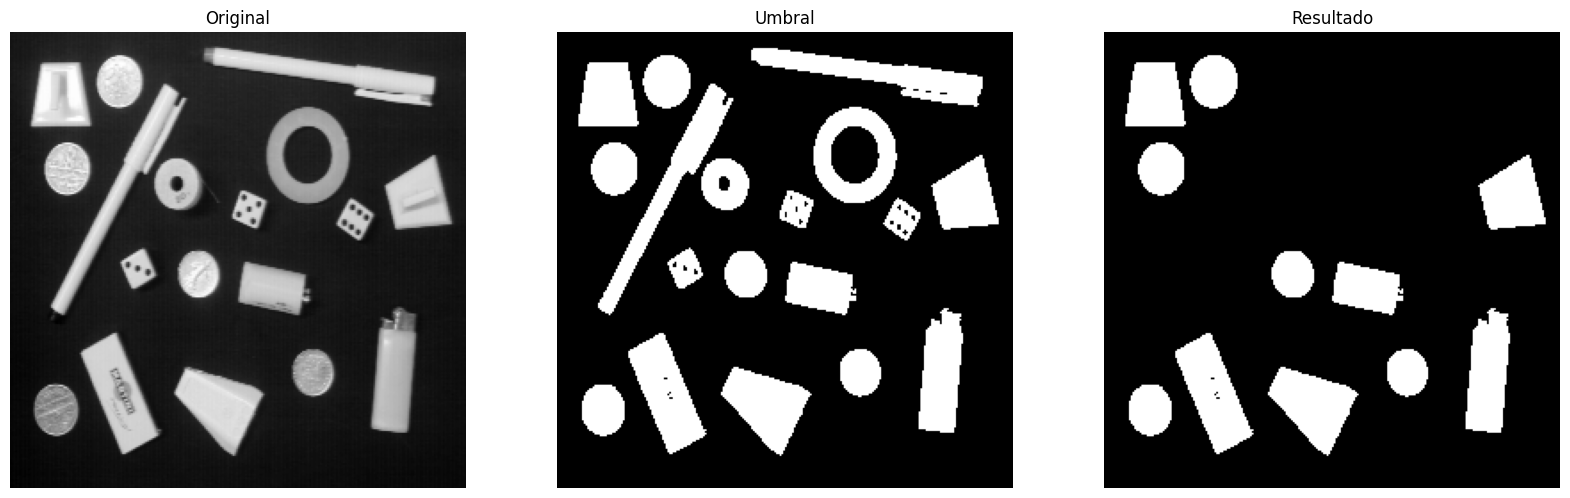

In [44]:
OBJECTS = cv2.imread('../img/OBJECTS.png', cv2.IMREAD_GRAYSCALE)
STRUCTURE = footprint_rectangle((17,17))
thres_value, thres_objs = cv2.threshold(OBJECTS, 70, 255, cv2.THRESH_BINARY)
eroded = erosion(thres_objs, STRUCTURE)

# Usar la erosión como semilla (marcador) y reconstruir sobre la imagen original
resultado = np.zeros_like(thres_objs, dtype=bool)
semillas = np.argwhere(eroded)

for y,x in semillas:
    mascara = flood(thres_objs, (y,x))
    resultado = cv2.bitwise_or(resultado.astype(np.uint8), mascara.astype(np.uint8))    
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(OBJECTS, cmap='gray')
plt.title('Original')
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(thres_objs, cmap='gray')
plt.title('Umbral')
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(resultado, cmap='gray')
plt.title('Resultado')
plt.axis("off")
plt.show()

(10, 10)


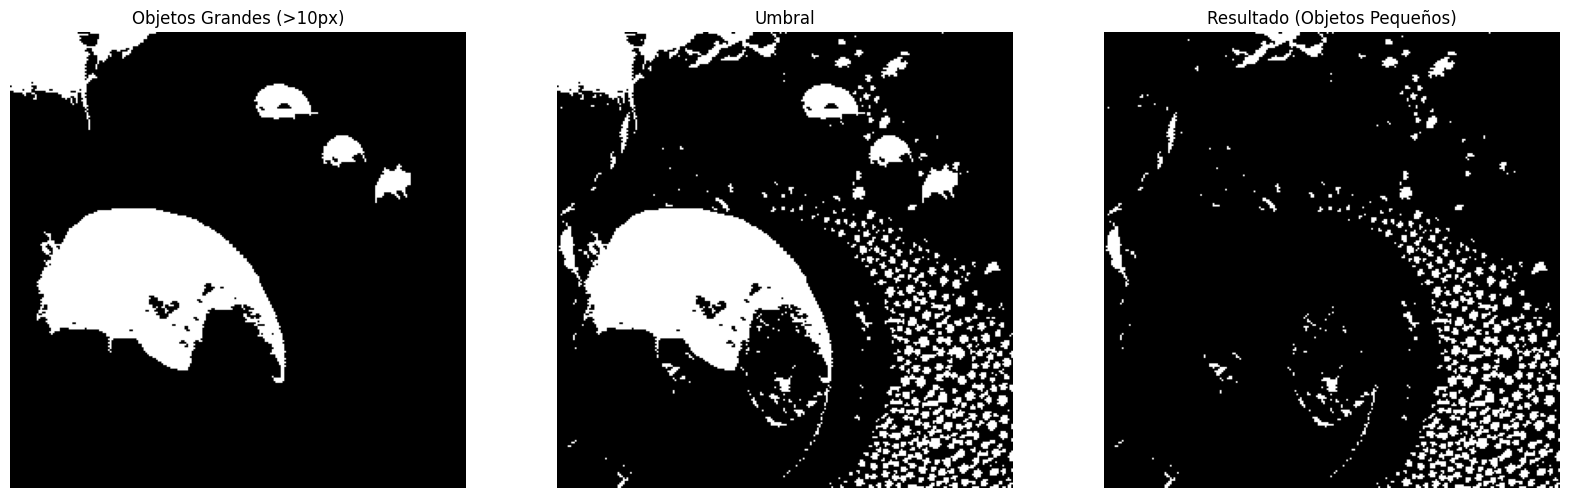

In [45]:
MEB = cv2.imread('../img/MEB.png', cv2.IMREAD_GRAYSCALE)
# Umbralización
_, thresh_meb = cv2.threshold(MEB, 60, 255, cv2.THRESH_BINARY)

# Vemos los objetos más grandes de 10 px 
STRUCTURE = footprint_rectangle((10, 10))
print(STRUCTURE.shape)
# Erosionar para obtener semillas de objetos grandes
eroded_meb = erosion(thresh_meb, STRUCTURE)

# Reconstruir los objetos grandes usando reconstruction
objetos_grandes = reconstruction(eroded_meb, thresh_meb, method='dilation')

# Resultado: eliminar los objetos grandes (quedan solo los pequeños)
resultado = cv2.subtract(thresh_meb.astype(np.uint8), objetos_grandes.astype(np.uint8))

plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.imshow(objetos_grandes, cmap='gray')
plt.title('Objetos Grandes (>10px)')
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(thresh_meb, cmap='gray')
plt.title('Umbral')
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(resultado, cmap='gray')
plt.title('Resultado (Objetos Pequeños)')
plt.axis("off")
plt.show()